In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
import diffrax
from jaxtyping import Float

import dismech_jax as djx

from util import TripletModel, validate_model, train_model, get_base_rod
from animate import animate

jax.config.update("jax_enable_x64", True)


In [2]:
class MLP(eqx.Module):
    layer1: eqx.nn.Linear
    layer2: eqx.nn.Linear

    def __init__(self, in_features: int, hidden_size: int, key: jax.Array):
        key1, key2 = jax.random.split(key)
        self.layer1 = eqx.nn.Linear(in_features, hidden_size, key=key1)
        self.layer2 = eqx.nn.Linear(hidden_size, 1, key=key2)

        self.layer1 = eqx.tree_at(
            lambda l: l.weight, self.layer1, self.layer1.weight * 1e-2
        )
        self.layer2 = eqx.tree_at(
            lambda l: l.weight, self.layer2, self.layer2.weight * 1e-2
        )

    def __call__(self, x: jax.Array) -> jax.Array:
        x = jax.nn.softplus(self.layer1(x**2))
        x = self.layer2(x)
        return jax.nn.softplus(x[0])


class Example(TripletModel):
    K: jax.Array  # = eqx.field(static=True)
    mlp: MLP

    def __init__(self, der_K: jax.Array, key: jax.Array):
        self.K = der_K
        self.mlp = MLP(3, 20, key)

    def __call__(self, del_strain: Float[jax.Array, "5"]) -> Float[jax.Array, ""]:
        # return 0.5 * jnp.sum(self.K * del_strain**2) + self.mlp(del_strain)
        strains_of_use = jnp.concatenate([del_strain[:2], del_strain[3:4]])  # skip the 3rd  and 5th component
        return self.mlp(strains_of_use)
        # return self.mlp(del_strain[:3])
        # return 0.5 * jnp.sum(self.K * del_strain**2)



In [3]:

validate_model(Example)

final_model, init_K, train_history, valid_history = train_model(Example, key=jax.random.PRNGKey(42), train_file="data/output_valid.npz", valid_file="data/output.npz", n_epochs=500, lr=1e-2)
# final_model, train_history, valid_history = train_model(Example, key=jax.random.PRNGKey(42), train_file="output_valid.npz", valid_file="output_valid.npz", n_epochs=100, lr=1e-2)

print( "initial K: ", init_K)
print( "learned K: ", final_model.K)

Step 0    | LR: 1.000e-02  | Train: 1.94635e+08  | Valid: 1.50508e+02  | K: [2.   0.01]
Step 10   | LR: 9.991e-03  | Train: 1.95134e-01  | Valid: 6.16952e-01  | K: [2.   0.01]
Step 20   | LR: 9.965e-03  | Train: 7.40829e-02  | Valid: 2.74672e-01  | K: [2.   0.01]
Step 30   | LR: 9.921e-03  | Train: 4.54449e-02  | Valid: 2.04455e-01  | K: [2.   0.01]
Step 40   | LR: 9.859e-03  | Train: 2.93011e-02  | Valid: 1.86884e-01  | K: [2.   0.01]
Step 50   | LR: 9.781e-03  | Train: 1.60913e-02  | Valid: 1.86589e-01  | K: [2.   0.01]
Step 60   | LR: 9.685e-03  | Train: 3.22765e-02  | Valid: 1.84318e-01  | K: [2.   0.01]
Step 70   | LR: 9.573e-03  | Train: 9.37384e-03  | Valid: 1.52955e-01  | K: [2.   0.01]
Step 80   | LR: 9.446e-03  | Train: 5.22747e-03  | Valid: 1.62773e-01  | K: [2.   0.01]
Step 90   | LR: 9.302e-03  | Train: 3.85411e-03  | Valid: 1.71991e-01  | K: [2.   0.01]
Step 100  | LR: 9.144e-03  | Train: 3.23842e-03  | Valid: 1.71992e-01  | K: [2.   0.01]
Step 110  | LR: 8.971e-03  | Tra

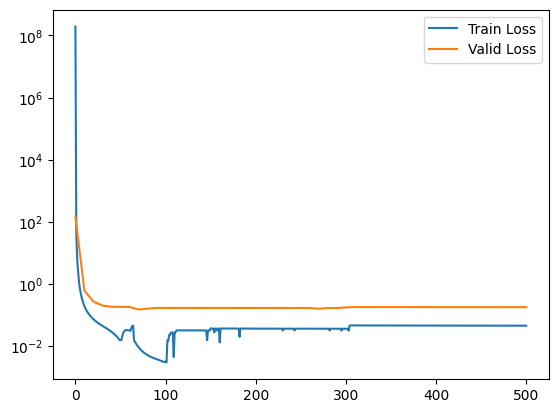

In [4]:
import matplotlib.pyplot as plt
train_np = np.asarray(train_history, dtype=float).reshape(-1)
valid_np = np.asarray(valid_history, dtype=float).reshape(-1)

idx_valid = np.where(valid_np != -1)[0]

plt.plot(np.arange(train_np.size), train_np, label="Train Loss")
plt.plot(idx_valid, valid_np[idx_valid], label="Valid Loss")
plt.yscale("log")
plt.legend()
plt.show()

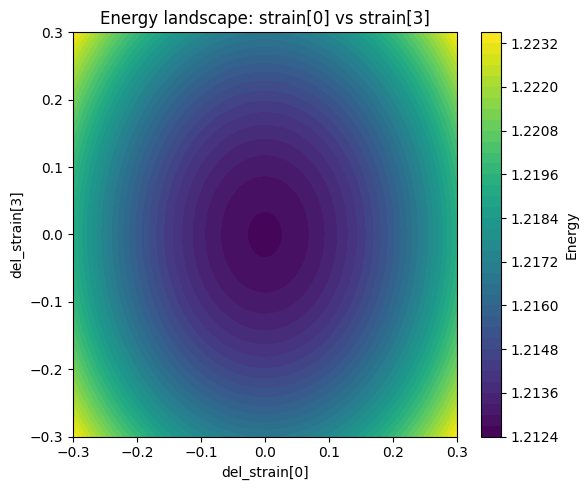

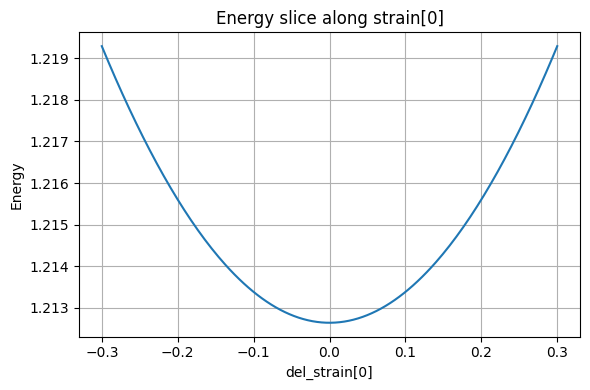

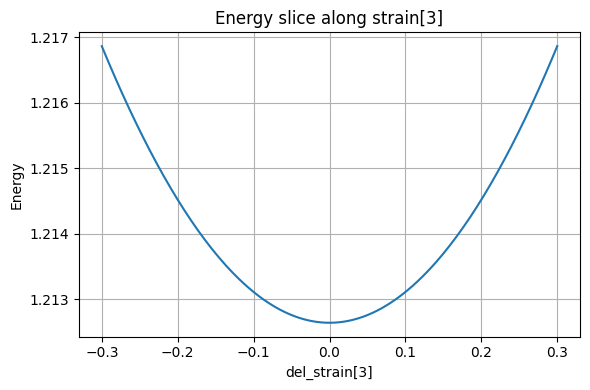

In [5]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt


def plot_energy_2d(
    model,
    idx1,
    idx2,
    s1_range=(-0.3, 0.3),
    s2_range=(-0.3, 0.3),
    n=200,
    strain_ref=None,
):
    """
    Plot E as a function of two strain components.

    Args:
        model: trained Example model
        idx1, idx2: indices of strain components to vary
        s1_range, s2_range: ranges for the two strains
        n: grid resolution
        strain_ref: base strain vector (default = zeros)
    """

    if strain_ref is None:
        strain_ref = jnp.zeros(5)

    s1_vals = jnp.linspace(*s1_range, n)
    s2_vals = jnp.linspace(*s2_range, n)
    S1, S2 = jnp.meshgrid(s1_vals, s2_vals, indexing="xy")

    def energy_at(s1, s2):
        strain = strain_ref
        strain = strain.at[idx1].set(s1)
        strain = strain.at[idx2].set(s2)
        return model(strain)

    # vectorize over grid
    E = jax.vmap(
        lambda row_s1, row_s2: jax.vmap(energy_at)(row_s1, row_s2)
    )(S1, S2)

    # convert to numpy for plotting
    S1_np = np.array(S1)
    S2_np = np.array(S2)
    E_np = np.array(E)

    plt.figure(figsize=(6, 5))
    cp = plt.contourf(S1_np, S2_np, E_np, levels=40)
    plt.colorbar(cp, label="Energy")
    plt.xlabel(f"del_strain[{idx1}]")
    plt.ylabel(f"del_strain[{idx2}]")
    plt.title(f"Energy landscape: strain[{idx1}] vs strain[{idx2}]")
    plt.tight_layout()
    plt.show()


def plot_energy_1d(
    model,
    idx,
    s_range=(-0.3, 0.3),
    n=200,
    strain_ref=None,
):
    """
    Plot E as a function of a single strain component.

    Args:
        model: trained Example model
        idx: index of strain component to vary
        s_range: range for the strain
        n: number of points
        strain_ref: base strain vector (default = zeros)
    """

    if strain_ref is None:
        strain_ref = jnp.zeros(5)

    s_vals = jnp.linspace(*s_range, n)

    def energy_at(s):
        strain = strain_ref
        strain = strain.at[idx].set(s)
        return model(strain)

    E = jax.vmap(energy_at)(s_vals)

    # convert to numpy
    s_vals_np = np.array(s_vals)
    E_np = np.array(E)

    plt.figure(figsize=(6, 4))
    plt.plot(s_vals_np, E_np)
    plt.xlabel(f"del_strain[{idx}]")
    plt.ylabel("Energy")
    plt.title(f"Energy slice along strain[{idx}]")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_energy_2d(final_model, idx1=0, idx2=3)
plot_energy_1d(final_model, idx=0)
plot_energy_1d(final_model, idx=3)

In [6]:
from util import TestCase

train = TestCase.from_npz("data/output.npz")
valid = TestCase.from_npz("data/output.npz")
# train = TestCase.from_npz("data/output_valid.npz")
# valid = TestCase.from_npz("data/output_valid.npz")
print("Train:")
print("fixed idx:", train.bc.idx_b)
print("slope:", train.bc.xb_m)
print("intercept:", train.bc.xb_c)
print("Valid:")
print("fixed idx:", valid.bc.idx_b)
print("slope:", valid.bc.xb_m)
print("intercept:", valid.bc.xb_c)
lambdas = jnp.linspace(0.0, 1.0, valid.qs.shape[0])


Train:
fixed idx: [ 0  1  2  3  7  8  9 10]
slope: [[0.  0.  0.  0.  0.  0.5 0.  0. ]]
intercept: [0.  0.  0.  0.  0.  0.5 0.  0. ]
Valid:
fixed idx: [ 0  1  2  3  7  8  9 10]
slope: [[0.  0.  0.  0.  0.  0.5 0.  0. ]]
intercept: [0.  0.  0.  0.  0.  0.5 0.  0. ]


In [7]:

base, aux, _ = get_base_rod()
rods = base.with_bc(valid.bc)
pred = rods.solve(final_model, lambdas, aux, max_dlambda=5e-3, iters=5, ls_steps=10)[0]
animate(pred)

In [8]:
animate(valid.qs)

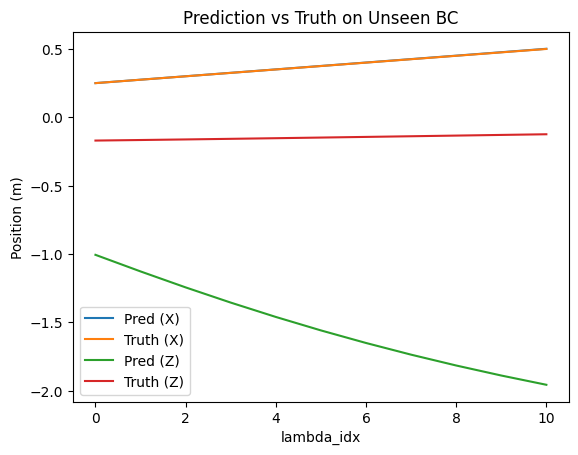

In [9]:
import matplotlib.pyplot as plt

plt.plot(pred[:, 4], label="Pred (X)")
plt.plot(valid.qs[:, 4], label="Truth (X)")
# plt.plot(pred[:, 5], label="Pred (Y)")
# plt.plot(valid.qs[:, 5], label="Truth (Y)")
plt.plot(pred[:, 6], label="Pred (Z)")
plt.plot(valid.qs[:, 6], label="Truth (Z)")
plt.legend()
plt.title("Prediction vs Truth on Unseen BC")
plt.xlabel("lambda_idx")
plt.ylabel("Position (m)")
plt.show()

In [10]:
print("Training BC:")
print("init: ", train.qs[0, 8:11])
print("final: ", train.qs[-1, 8:11])

print("Validation BC:")
print("init: ", valid.qs[0, 8:11])
print("final: ", valid.qs[-1, 8:11])

Training BC:
init:  [0.5 0.  0. ]
final:  [1. 0. 0.]
Validation BC:
init:  [0.5 0.  0. ]
final:  [1. 0. 0.]


In [11]:
print("initial position of the middle node in the training data: ", train.qs[0, 4:7])
print("final position of the middle node in the training data: ", train.qs[-1, 4:7])

initial position of the middle node in the training data:  [ 2.50000000e-01  3.61652220e-12 -1.69941712e-01]
final position of the middle node in the training data:  [ 4.99999146e-01 -9.07533152e-06 -1.23843111e-01]


In [12]:
print("initial position of the middle node in the validation data: ", valid.qs[0, 4:7])
print("final position of the middle node in the validation data: ", valid.qs[-1, 4:7])

initial position of the middle node in the validation data:  [ 2.50000000e-01  3.61652220e-12 -1.69941712e-01]
final position of the middle node in the validation data:  [ 4.99999146e-01 -9.07533152e-06 -1.23843111e-01]


In [13]:
print("initial position of the middle node in the prediction: ", pred[0, 4:7])
print("final position of the middle node in the prediction: ", pred[-1, 4:7])

initial position of the middle node in the prediction:  [ 0.25021936  0.         -1.0056039 ]
final position of the middle node in the prediction:  [ 0.50129046  0.         -1.95598864]
